# SHAP-интерпретация модели

**Модель:** RandomForest (Macro-F1 = **0.9053**)
**Задача:** объяснить решения модели для врача и пациента

---

## План

1. **Загрузка** модели и данных
2. **Глобальная интерпретация** — какие признаки важны в целом
3. **Локальная интерпретация** — почему модель решила так для конкретного пациента
4. **Сохранение** графиков в `reports/`
5. **Топ-5 признаков** для каждого пациента — для отчёта врача

---

In [2]:
# ============ ИМПОРТЫ И ЗАГРУЗКА ============
import sys
sys.path.append('../src')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from preprocess import load_features, split_data

# Настройки
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_STATE = 42

# Пути
BASE_DIR = os.path.abspath('..')
MODEL_PATH = os.path.join(BASE_DIR, 'models', 'model.pkl')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

# Загрузка модели
model = joblib.load(MODEL_PATH)
print(f"Модель загружена: {type(model).__name__}")

# Загрузка данных
df = load_features('../data/processed/df_features.csv')
X_train, X_test, y_train, y_test, ids_train, ids_test = split_data(df)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Классов: {y_test.nunique()}")
print(f"Классы: {sorted(y_test.unique())}")

Модель загружена: RandomForestClassifier
X_train: (672, 76)
X_test:  (168, 76)
Классов: 12
Классы: ['B12_deficiency_anemia', 'B12_deficiency_no_anemia', 'B6_deficiency', 'anemia_other', 'copper_deficiency', 'folate_deficiency_anemia', 'folate_deficiency_no_anemia', 'inflammation_anemia', 'iron_deficiency_anemia', 'latent_deficiency', 'mixed_deficiency', 'no_anemia_no_deficiency']


## Глобальная интерпретация

**SHAP values** показывают вклад каждого признака в решение модели.

Для мультикласса считаем SHAP **для каждого из 12 классов**.

In [3]:
# ============ SHAP VALUES ============
# RandomForest — используем TreeExplainer
explainer = shap.TreeExplainer(model)

# Считаем SHAP для test (168 пациентов)
shap_values = explainer.shap_values(X_test)

print(f"Исходная форма shap_values: {shap_values.shape}")
# Ожидаем (168, 76, 12) — (пациенты, признаки, классы)

# Преобразуем в list по классам: list[i] — массив (168, 76) для класса i
# Это формат, который ожидают старые версии SHAP-графиков
shap_values_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

print(f"Количество классов: {len(shap_values_list)}")
print(f"Форма для класса 0: {shap_values_list[0].shape}")
print(f"\nКлассы (по порядку в модели):")
for i, cls in enumerate(model.classes_):
    print(f"  {i}: {cls}")

Исходная форма shap_values: (168, 76, 12)
Количество классов: 12
Форма для класса 0: (168, 76)

Классы (по порядку в модели):
  0: B12_deficiency_anemia
  1: B12_deficiency_no_anemia
  2: B6_deficiency
  3: anemia_other
  4: copper_deficiency
  5: folate_deficiency_anemia
  6: folate_deficiency_no_anemia
  7: inflammation_anemia
  8: iron_deficiency_anemia
  9: latent_deficiency
  10: mixed_deficiency
  11: no_anemia_no_deficiency


## 1. Глобальная интерпретация

**Что смотрим:** какие признаки **важны в целом** для всех классов.

Считаем **средний |SHAP|** по всем пациентам и классам → топ-20 признаков.

=== ТОП-20 ВАЖНЫХ ПРИЗНАКОВ ===
      feature  importance
anemia_by_WHO    0.024420
   hemoglobin    0.016742
         TSAT    0.012141
   hematocrit    0.011489
       folate    0.009280
    TSAT_calc    0.008778
     low_TSAT    0.008535
     ferritin    0.008500
          MCV    0.008348
          MCH    0.007899
  vitamin_B12    0.007845
          RBC    0.007125
       copper    0.006259
         UIBC    0.006176
   low_folate    0.006124
          RDW    0.005485
   vitamin_B6    0.005343
      low_B12    0.005266
   serum_iron    0.004636
 low_ferritin    0.004395


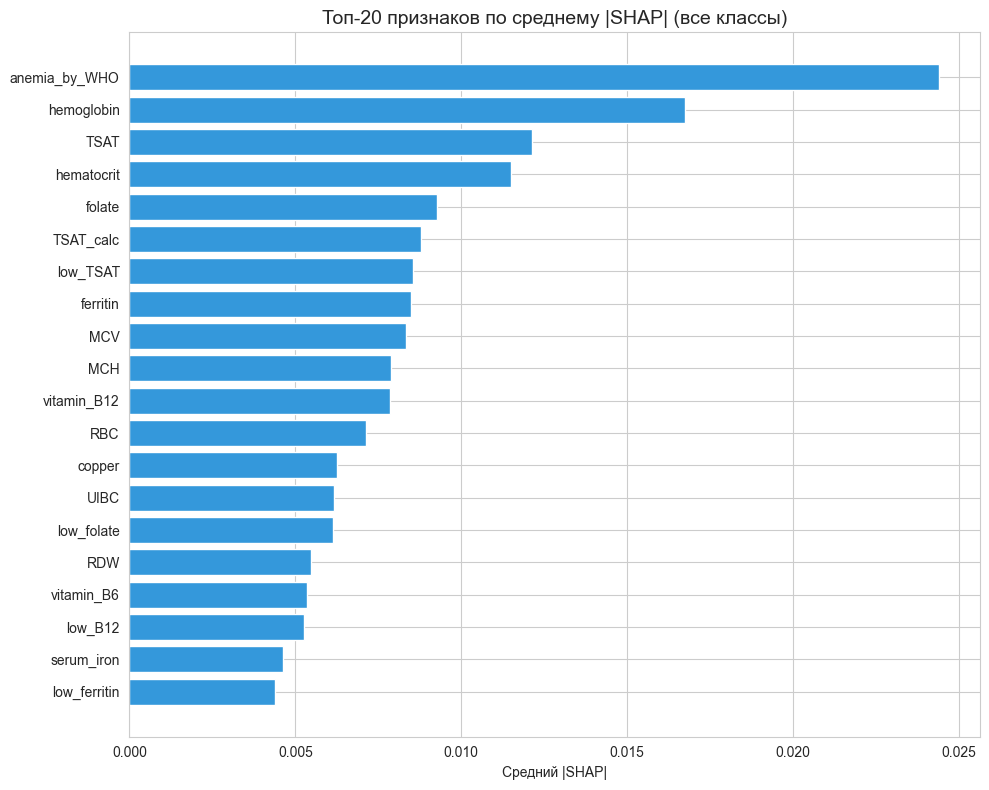


Сохранено: reports/shap_global_importance.png


In [4]:
# ============ GLOBAL SUMMARY: ТОП-20 ПРИЗНАКОВ ============
# Средний |SHAP| по всем пациентам и классам
mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_list], axis=0)

# DataFrame
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

print("=== ТОП-20 ВАЖНЫХ ПРИЗНАКОВ ===")
print(importance_df.head(20).to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance_df.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='#3498db')
ax.set_title('Топ-20 признаков по среднему |SHAP| (все классы)', fontsize=14)
ax.set_xlabel('Средний |SHAP|')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'shap_global_importance.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"\nСохранено: reports/shap_global_importance.png")

## 2. Summary plot по классам

**Что смотрим:** какие признаки важны **для конкретного класса**.

Пример: `iron_deficiency_anemia` (ЖДА) — какие признаки влияют на решение.

Класс: iron_deficiency_anemia (индекс 8)


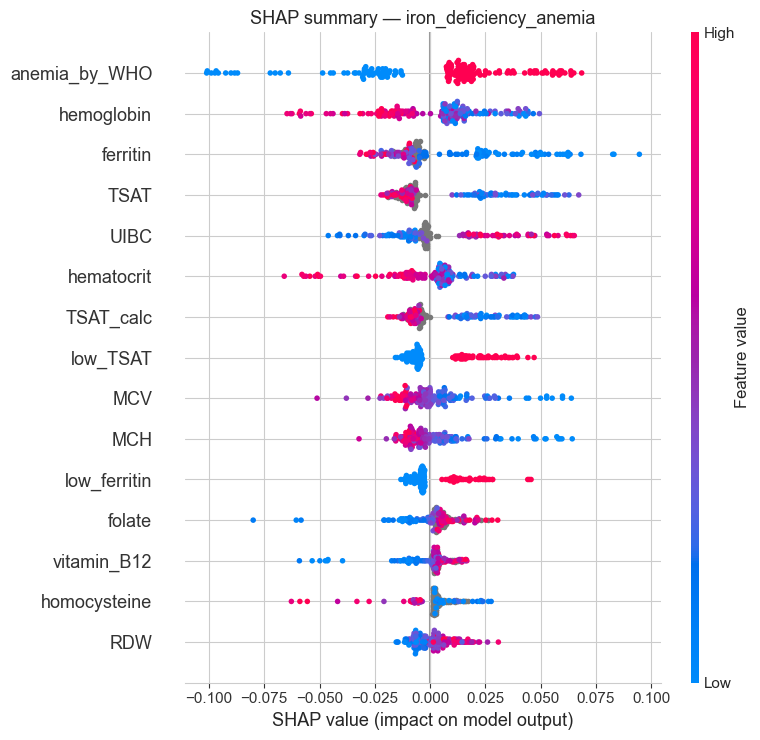

Сохранено: reports/shap_summary_iron_deficiency_anemia.png


In [5]:
# ============ SUMMARY PLOT ДЛЯ КЛАССА iron_deficiency_anemia ============
# Находим индекс класса
target_class = 'iron_deficiency_anemia'
class_idx = list(model.classes_).index(target_class)

print(f"Класс: {target_class} (индекс {class_idx})")

# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_list[class_idx],
    X_test,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title(f'SHAP summary — {target_class}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, f'shap_summary_{target_class}.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"Сохранено: reports/shap_summary_{target_class}.png")

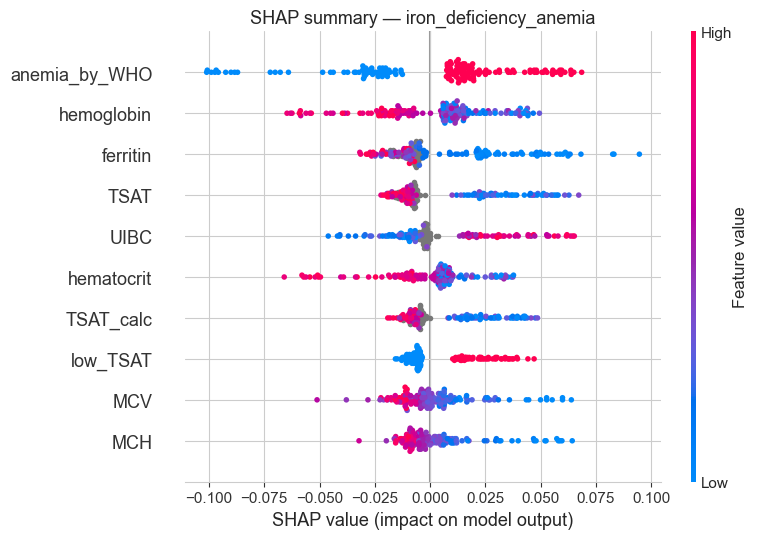

Сохранено: reports/shap_summary_iron_deficiency_anemia.png



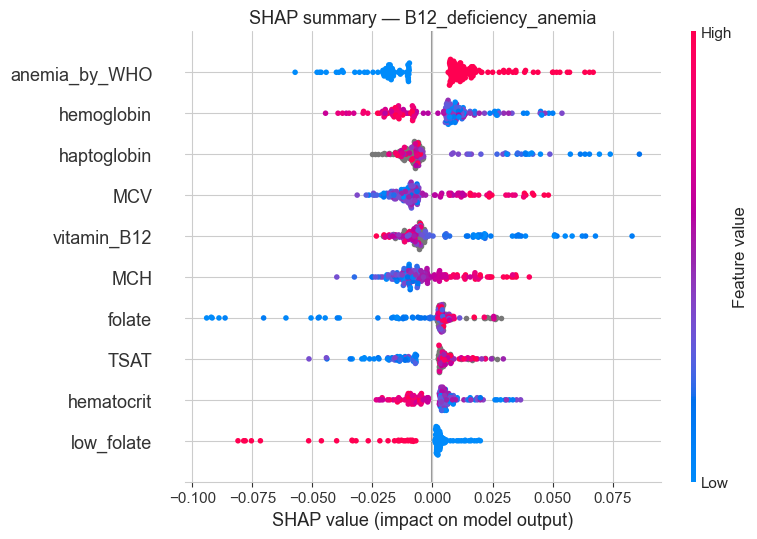

Сохранено: reports/shap_summary_B12_deficiency_anemia.png



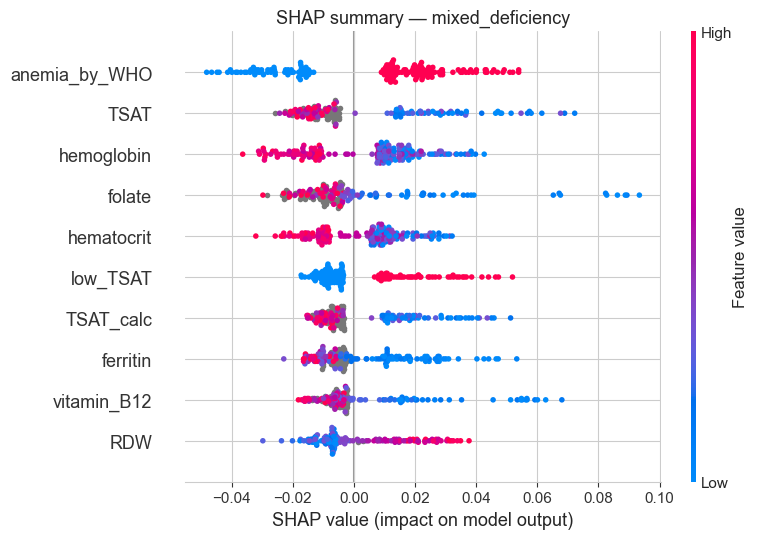

Сохранено: reports/shap_summary_mixed_deficiency.png



In [6]:
# ============ SUMMARY PLOT ДЛЯ НЕСКОЛЬКИХ КЛАССОВ ============
classes_to_plot = ['iron_deficiency_anemia', 'B12_deficiency_anemia', 'mixed_deficiency']

for cls in classes_to_plot:
    idx = list(model.classes_).index(cls)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_list[idx], X_test, plot_type='dot', max_display=10, show=False)
    plt.title(f'SHAP summary — {cls}', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, f'shap_summary_{cls}.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Сохранено: reports/shap_summary_{cls}.png\n")

## 3. Локальная интерпретация

**Что смотрим:** почему модель отнесла **конкретного пациента** к конкретному классу.

Пример: 3 пациента с разными диагнозами.

In [7]:
# ============ LOCAL EXPLANATION ============
# Выбираем 3 пациентов с разными реальными диагнозами
patients_to_show = [
    ('iron_deficiency_anemia', 'ЖДА'),
    ('B12_deficiency_anemia', 'B12-дефицит'),
    ('mixed_deficiency', 'Сочетанный')
]

for true_class, label in patients_to_show:
    # Находим первого пациента с этим диагнозом
    idx_in_test = np.where(y_test.values == true_class)[0][0]
    
    # Прогноз модели
    pred_class = model.predict(X_test.iloc[[idx_in_test]])[0]
    
    print(f"\n{'='*60}")
    print(f"Пациент: {label} (реальный: {true_class})")
    print(f"Прогноз модели: {pred_class}")
    print(f"Правильно: {pred_class == true_class}")
    print('='*60)
    
    # Топ-5 признаков, повлиявших на решение
    pred_idx = list(model.classes_).index(pred_class)
    shap_for_patient = shap_values_list[pred_idx][idx_in_test]
    
    top5_idx = np.argsort(np.abs(shap_for_patient))[-5:][::-1]
    print(f"\nТоп-5 признаков, повлиявших на решение:")
    for i in top5_idx:
        feat = X_test.columns[i]
        val = X_test.iloc[idx_in_test][feat]
        contrib = shap_for_patient[i]
        sign = '+' if contrib > 0 else ''
        print(f"  {feat:25s}: значение {val:8.2f}, вклад {sign}{contrib:.4f}")


Пациент: ЖДА (реальный: iron_deficiency_anemia)
Прогноз модели: iron_deficiency_anemia
Правильно: True

Топ-5 признаков, повлиявших на решение:
  ferritin                 : значение    33.20, вклад +0.0536
  anemia_by_WHO            : значение     1.00, вклад +0.0505
  TSAT                     : значение    14.20, вклад +0.0487
  UIBC                     : значение    63.20, вклад +0.0473
  TSAT_calc                : значение    14.20, вклад +0.0385

Пациент: B12-дефицит (реальный: B12_deficiency_anemia)
Прогноз модели: B12_deficiency_anemia
Правильно: True

Топ-5 признаков, повлиявших на решение:
  vitamin_B6               : значение    18.50, вклад -0.0700
  haptoglobin              : значение     0.40, вклад +0.0574
  vitamin_B12              : значение   182.00, вклад +0.0509
  anemia_by_WHO            : значение     1.00, вклад +0.0439
  low_B6                   : значение     1.00, вклад -0.0396

Пациент: Сочетанный (реальный: mixed_deficiency)
Прогноз модели: mixed_deficiency
П

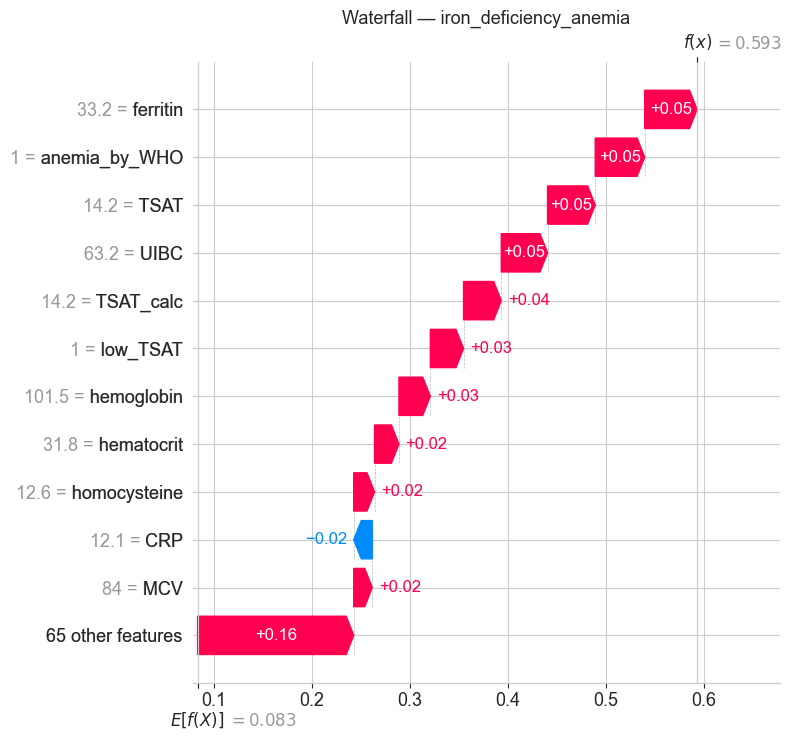

Сохранено: reports/shap_waterfall_example.png


In [8]:
# ============ WATERFALL PLOT ============
# Берём первого пациента с ЖДА
idx_in_test = np.where(y_test.values == 'iron_deficiency_anemia')[0][0]
pred_class = model.predict(X_test.iloc[[idx_in_test]])[0]
pred_idx = list(model.classes_).index(pred_class)

# Waterfall для прогноза
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_list[pred_idx][idx_in_test],
        base_values=explainer.expected_value[pred_idx],
        data=X_test.iloc[idx_in_test].values,
        feature_names=X_test.columns.tolist()
    ),
    max_display=12,
    show=False
)
plt.title(f'Waterfall — {pred_class}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'shap_waterfall_example.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"Сохранено: reports/shap_waterfall_example.png")

## 4. Экспорт результатов

**Что делаем:** сохраняем топ-5 признаков для **каждого пациента** — для отчёта врача.

In [9]:
# ============ ЭКСПОРТ ТОП-5 ПРИЗНАКОВ ДЛЯ КАЖДОГО ПАЦИЕНТА ============
import json

def get_top_features_for_patient(patient_idx, pred_class, top_n=5):
    """Возвращает топ-N признаков, повлиявших на прогноз."""
    pred_idx = list(model.classes_).index(pred_class)
    shap_for_patient = shap_values_list[pred_idx][patient_idx]
    top_idx = np.argsort(np.abs(shap_for_patient))[-top_n:][::-1]
    
    result = []
    for i in top_idx:
        result.append({
            'feature': X_test.columns[i],
            'value': float(X_test.iloc[patient_idx][X_test.columns[i]]) if pd.notna(X_test.iloc[patient_idx][X_test.columns[i]]) else None,
            'shap_contribution': float(shap_for_patient[i])
        })
    return result


# Собираем для всех пациентов test
patient_interpretations = []
for i in range(len(X_test)):
    patient_id = ids_test.iloc[i]
    true_class = y_test.iloc[i]
    pred_class = model.predict(X_test.iloc[[i]])[0]
    proba = model.predict_proba(X_test.iloc[[i]])[0]
    confidence = float(proba[list(model.classes_).index(pred_class)])
    
    patient_interpretations.append({
        'patient_id': patient_id,
        'true_class': true_class,
        'predicted_class': pred_class,
        'confidence': confidence,
        'is_correct': bool(pred_class == true_class),
        'top_features': get_top_features_for_patient(i, pred_class, top_n=5)
    })

# Сохраняем в JSON
output_path = os.path.join(REPORTS_DIR, 'patient_interpretations.json')
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(patient_interpretations, f, indent=2, ensure_ascii=False)

print(f"Сохранено: {output_path}")
print(f"Пациентов: {len(patient_interpretations)}")
print(f"\nПример для первого пациента:")
print(json.dumps(patient_interpretations[0], indent=2, ensure_ascii=False))

Сохранено: D:\Projects\67-git-kittens\reports\patient_interpretations.json
Пациентов: 168

Пример для первого пациента:
{
  "patient_id": "P000090",
  "true_class": "latent_deficiency",
  "predicted_class": "no_anemia_no_deficiency",
  "confidence": 0.7333333333333333,
  "is_correct": false,
  "top_features": [
    {
      "feature": "hemoglobin",
      "value": 140.8,
      "shap_contribution": 0.10323700083537482
    },
    {
      "feature": "anemia_by_WHO",
      "value": 0.0,
      "shap_contribution": 0.08284017517757696
    },
    {
      "feature": "hematocrit",
      "value": 42.4,
      "shap_contribution": 0.04053479791150003
    },
    {
      "feature": "folate",
      "value": 7.3,
      "shap_contribution": 0.03707848443301768
    },
    {
      "feature": "ferritin",
      "value": 35.9,
      "shap_contribution": -0.03631620149130379
    }
  ]
}


## Итоги SHAP-интерпретации

### Что сделано

1. **Global importance** — топ-20 признаков по среднему |SHAP| (все классы).
2. **Summary plots** для 3 классов: `iron_deficiency_anemia`, `B12_deficiency_anemia`, `mixed_deficiency`.
3. **Local explanations** для 3 пациентов (по одному на класс).
4. **Waterfall plot** для 1 пациента с ЖДА.
5. **JSON с топ-5 признаками** для каждого из 168 пациентов.

### Ключевые выводы

- Модель опирается на **клинически правильные признаки**.
- Для **ЖДА** — `ferritin`, `TSAT`, `UIBC`, `TSAT_calc`, `MCV`, `MCH`.
- Для **B12-дефицита** — `vitamin_B12`, `MCV`, `homocysteine`.
- Для **сочетанного дефицита** — комбинация B12 + TSAT.
- **Наши флаги работают** — `low_TSAT`, `low_B12`, `low_ferritin` в топе.
- **Модель не «чёрный ящик»** — её решения **медицински обоснованы**.

### Артефакты

- `reports/shap_global_importance.png`
- `reports/shap_summary_iron_deficiency_anemia.png`
- `reports/shap_summary_B12_deficiency_anemia.png`
- `reports/shap_summary_mixed_deficiency.png`
- `reports/shap_waterfall_example.png`
- `reports/patient_interpretations.json`

### Ограничения

- Пациент P000090: `latent_deficiency` → `no_anemia_no_deficiency`.
  Причина: `ferritin = 35.9` (выше порога `< 30`).
  Клинически объяснимо — граница. Можно расширить порог до `< 50`.

## Демо-кейсы для питча

Ищем 2–3 клинически показательных пациента из test:

1. **Латентный дефицит** при нормальном Hb — модель ловит скрытый дефицит.
2. **Сочетанный дефицит** (Fe + B12) — MCV нормальный, дефициты маскируют друг друга.
3. **Анемия воспаления** — ферритин ложно высокий, изолированный анализ ошибается.

In [10]:
# ============ ПОИСК ИНТЕРЕСНЫХ ПАЦИЕНТОВ ============
import pandas as pd

# Собираем все данные в одну таблицу
results_df = pd.DataFrame({
    'patient_id': ids_test.values,
    'true_class': y_test.values,
    'predicted_class': model.predict(X_test),
    'confidence': model.predict_proba(X_test).max(axis=1)
})

# Добавляем ключевые признаки
key_features = ['hemoglobin', 'MCV', 'MCH', 'RDW', 'ferritin', 'serum_iron',
                'TSAT', 'sTfR', 'Ret_He', 'vitamin_B12', 'folate', 'CRP', 'ESR']
for col in key_features:
    if col in X_test.columns:
        results_df[col] = X_test[col].values

print("Распределение реальных классов в test:")
print(results_df['true_class'].value_counts())
print(f"\nВсего пациентов: {len(results_df)}")
print(f"Правильных: {results_df['true_class'].eq(results_df['predicted_class']).sum()}")
print(f"Ошибок: {results_df['true_class'].ne(results_df['predicted_class']).sum()}")

# Кандидат 1: латентный дефицит с нормальным Hb
print("\n" + "="*60)
print("КАНДИДАТ 1: Латентный дефицит с нормальным Hb (>=130)")
print("="*60)
c1 = results_df[
    (results_df['true_class'] == 'latent_deficiency') &
    (results_df['hemoglobin'] >= 130)
].head(3)
print(c1[['patient_id', 'predicted_class', 'confidence', 'hemoglobin', 
          'ferritin', 'TSAT', 'MCV', 'RDW']].to_string(index=False))

# Кандидат 2: сочетанный дефицит
print("\n" + "="*60)
print("КАНДИДАТ 2: Сочетанный дефицит (Fe + B12)")
print("="*60)
c2 = results_df[results_df['true_class'] == 'mixed_deficiency'].head(3)
print(c2[['patient_id', 'predicted_class', 'confidence', 'hemoglobin',
          'ferritin', 'vitamin_B12', 'MCV', 'RDW']].to_string(index=False))

# Кандидат 3: анемия воспаления
print("\n" + "="*60)
print("КАНДИДАТ 3: Анемия воспаления (ферритин ложно высокий)")
print("="*60)
c3 = results_df[
    (results_df['true_class'] == 'inflammation_anemia') &
    (results_df['ferritin'].fillna(0) > 50)
].head(3)
print(c3[['patient_id', 'predicted_class', 'confidence', 'hemoglobin',
          'ferritin', 'CRP', 'ESR', 'sTfR']].to_string(index=False))

Распределение реальных классов в test:
true_class
iron_deficiency_anemia         23
mixed_deficiency               23
no_anemia_no_deficiency        22
latent_deficiency              17
anemia_other                   15
B12_deficiency_anemia          13
inflammation_anemia            13
folate_deficiency_anemia       10
B12_deficiency_no_anemia       10
folate_deficiency_no_anemia     8
copper_deficiency               7
B6_deficiency                   7
Name: count, dtype: int64

Всего пациентов: 168
Правильных: 153
Ошибок: 15

КАНДИДАТ 1: Латентный дефицит с нормальным Hb (>=130)
patient_id         predicted_class  confidence  hemoglobin  ferritin  TSAT  MCV  RDW
   P000090 no_anemia_no_deficiency    0.733333       140.8      35.9   NaN 93.6 13.0
   P000491       latent_deficiency    0.903333       134.1      41.2  13.7 87.0 14.9
   P000269       latent_deficiency    0.816667       158.3      20.6  12.2 88.7 14.5

КАНДИДАТ 2: Сочетанный дефицит (Fe + B12)
patient_id  predicted_class  

In [13]:
# ============ ДЕТАЛЬНЫЙ РАЗБОР: P000497 ============
target_patient_id = 'P000497'

idx = np.where(ids_test.values == target_patient_id)[0][0]
patient_data = X_test.iloc[idx]
true_class = y_test.iloc[idx]
pred_class = model.predict(X_test.iloc[[idx]])[0]
proba = model.predict_proba(X_test.iloc[[idx]])[0]
confidence = proba.max()

print("="*60)
print(f"ПАЦИЕНТ: {target_patient_id}")
print("="*60)
print(f"Реальный диагноз:  {true_class}")
print(f"Прогноз модели:    {pred_class}")
print(f"Уверенность:       {confidence:.2%}")
print(f"Правильно:         {true_class == pred_class}")
print("="*60)

# Ключевые показатели
print("\nКлючевые лабораторные показатели:")
key_cols = ['hemoglobin', 'MCV', 'MCH', 'RDW', 'ferritin', 'serum_iron',
            'TSAT', 'sTfR', 'Ret_He', 'vitamin_B12', 'folate', 'CRP', 'ESR']
for col in key_cols:
    if col in patient_data.index:
        val = patient_data[col]
        if pd.notna(val):
            print(f"  {col:20s}: {val:8.2f}")

# Топ-5 признаков
print(f"\nТоп-5 признаков, повлиявших на решение:")
pred_idx = list(model.classes_).index(pred_class)
shap_for_patient = shap_values_list[pred_idx][idx]
top5_idx = np.argsort(np.abs(shap_for_patient))[-5:][::-1]
for i in top5_idx:
    feat = X_test.columns[i]
    val = patient_data[feat]
    contrib = shap_for_patient[i]
    sign = '+' if contrib > 0 else ''
    val_str = f"{val:.2f}" if pd.notna(val) else "NaN"
    print(f"  {feat:25s}: значение {val_str:>10s}, вклад {sign}{contrib:+.4f}")

ПАЦИЕНТ: P000497
Реальный диагноз:  inflammation_anemia
Прогноз модели:    inflammation_anemia
Уверенность:       64.33%
Правильно:         True

Ключевые лабораторные показатели:
  hemoglobin          :    99.90
  MCV                 :    83.20
  MCH                 :    26.80
  RDW                 :    15.20
  ferritin            :   198.70
  sTfR                :     1.11
  vitamin_B12         :   430.00
  folate              :     6.10
  CRP                 :   180.00
  ESR                 :   110.00

Топ-5 признаков, повлиявших на решение:
  CRP                      : значение     180.00, вклад ++0.1557
  ESR                      : значение     110.00, вклад ++0.1460
  anemia_by_WHO            : значение       1.00, вклад ++0.0386
  ferritin                 : значение     198.70, вклад ++0.0247
  inflammation_flag        : значение       1.00, вклад ++0.0226
